# Módulo 10 tarefa 03
Considere a mesma base de dados utilizada na tarefa 1 ```previsao_de_renda.csv```.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('previsao_de_renda.csv')
df['data_ref'] = pd.to_datetime(df['data_ref'])

# Variáveis qualitativas disponíveis
vars_qualitativas = ['sexo', 'posse_de_veiculo', 'posse_de_imovel', 
                     'tipo_renda', 'educacao', 'estado_civil', 'tipo_residencia']

1) Construa um gráfico de barras para avaliar a distribuição das variáveis qualitativas no tempo. Você acha que houve alguma alteração importante a ser investigada?

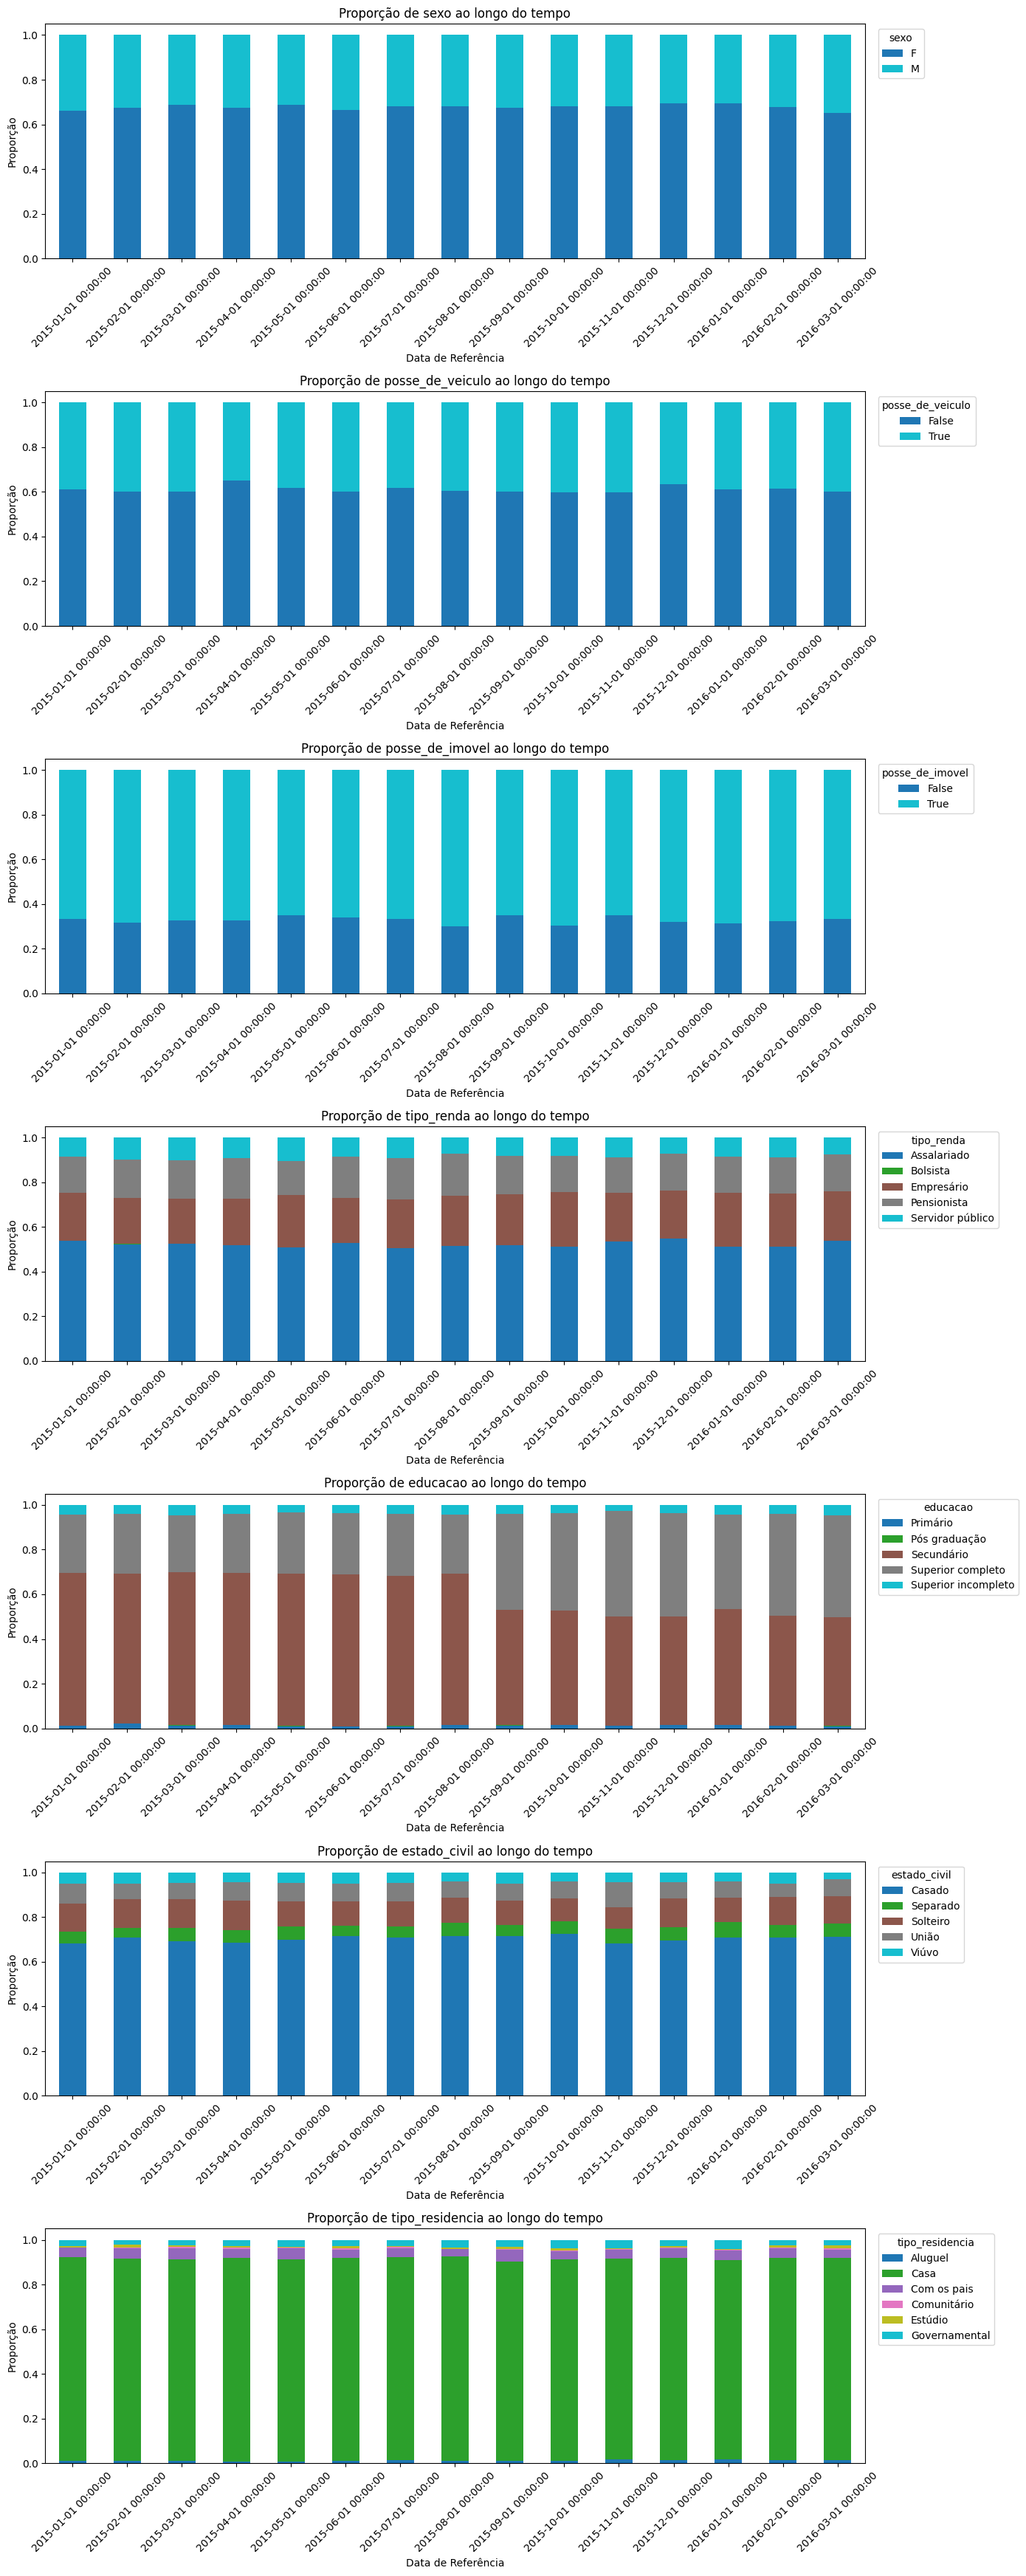

In [3]:
fig, axes = plt.subplots(len(vars_qualitativas), 1, figsize=(14, 5 * len(vars_qualitativas)))

for ax, var in zip(axes, vars_qualitativas):
    # Contagem proporcional por período
    proporcao = (
        df.groupby(['data_ref', var])
        .size()
        .unstack(fill_value=0)
    )
    proporcao = proporcao.div(proporcao.sum(axis=1), axis=0)  # normaliza para proporção
    proporcao.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
    ax.set_title(f'Proporção de {var} ao longo do tempo')
    ax.set_xlabel('Data de Referência')
    ax.set_ylabel('Proporção')
    ax.legend(title=var, bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

2) Para cada variável qualitativa, construa um gráfico mostrando as médias de cada nível da variável no tempo e avalie a estabilidade. Houve alguma alteração importante? Você acha que se pode utilizar essas variáveis em uma modelagem?

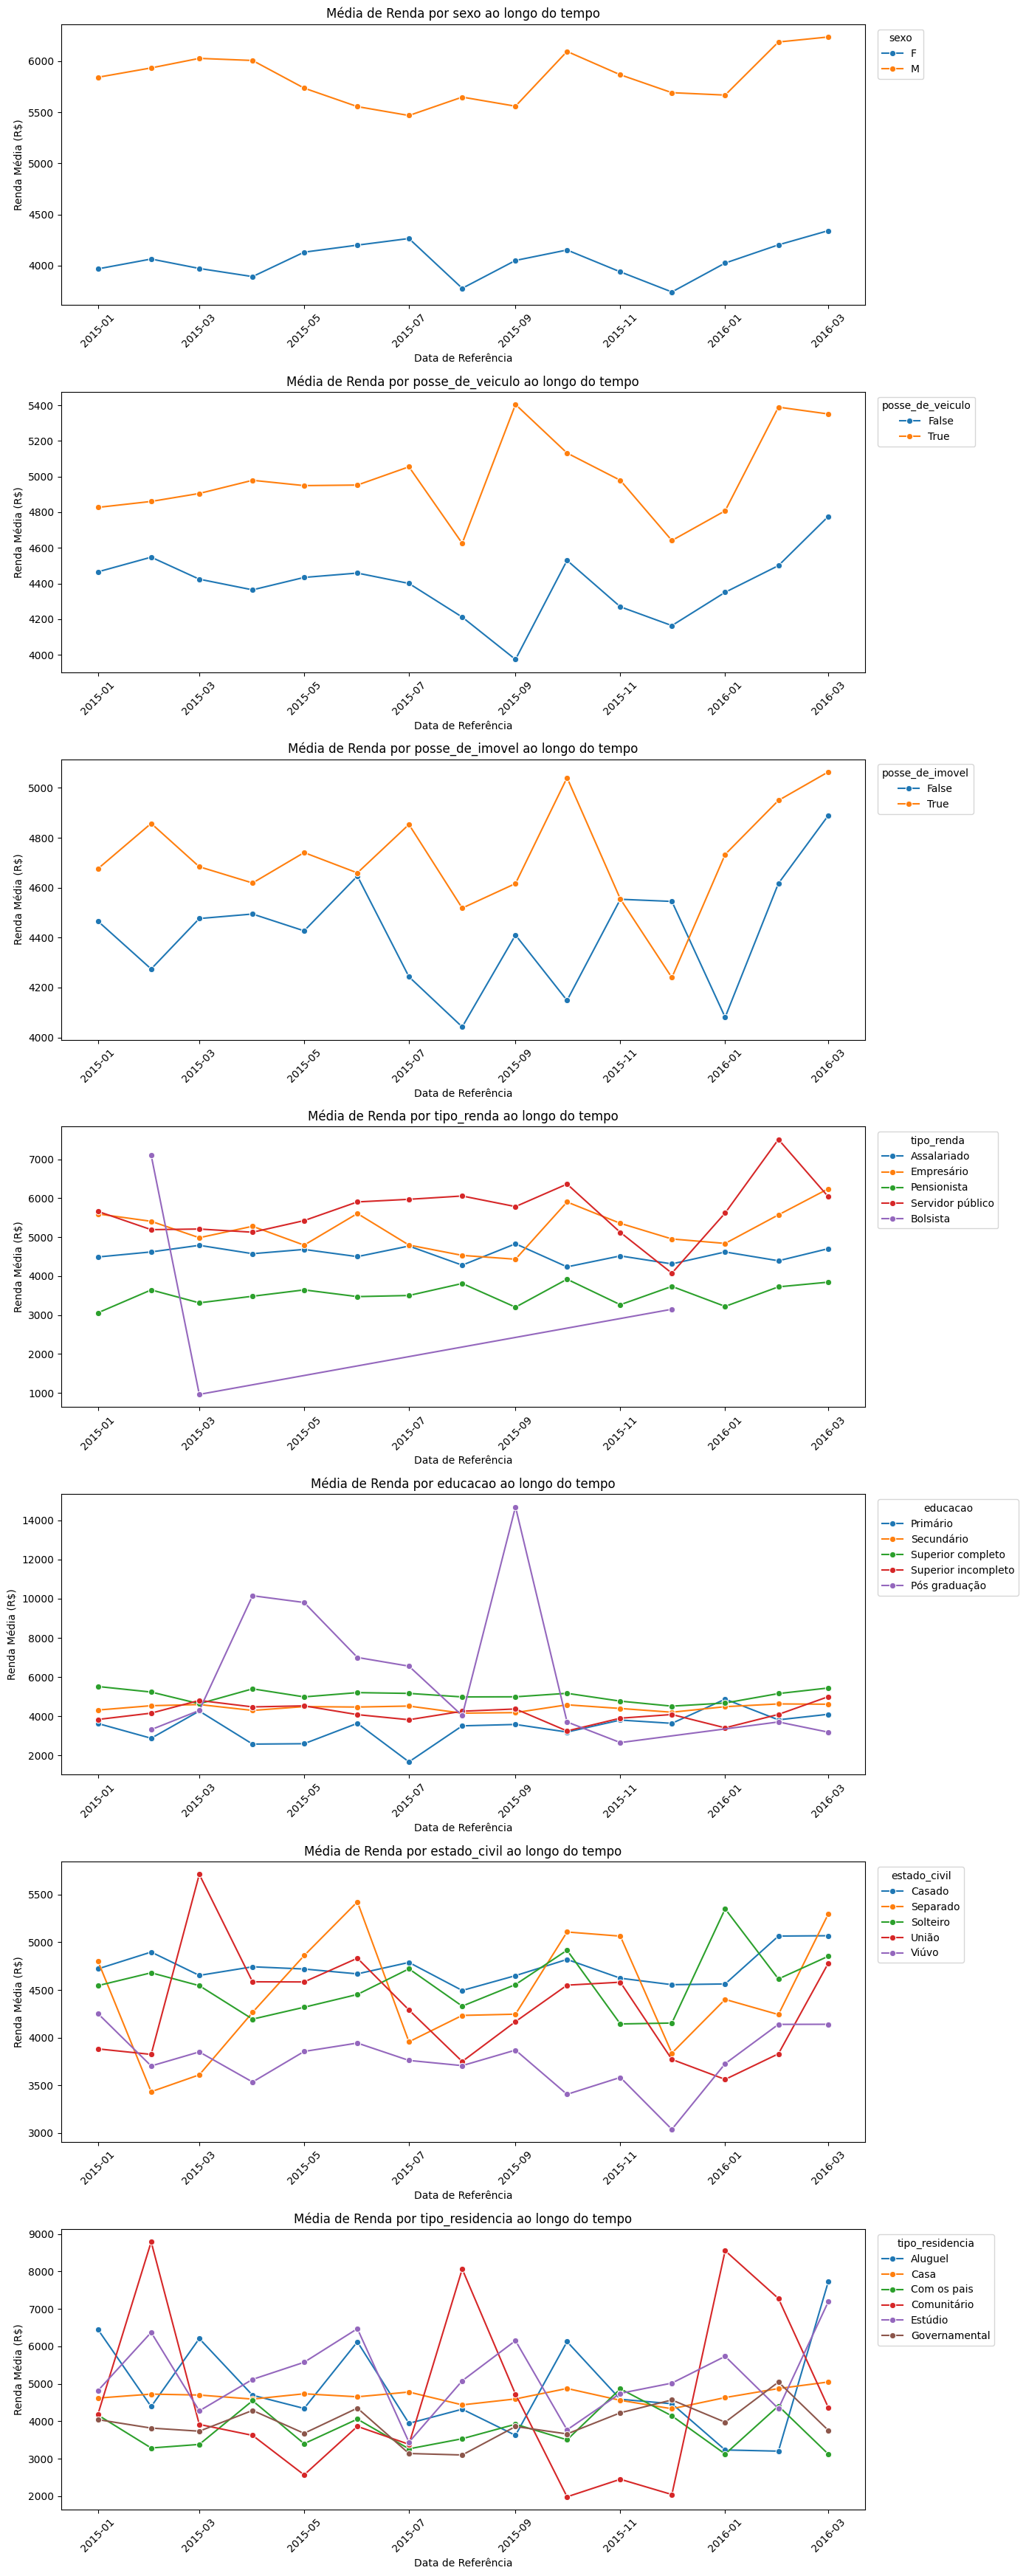


Critério de estabilidade:
- Linhas paralelas e sem cruzamentos indicam que a relação entre a variável e renda é estável.
- Oscilações bruscas ou cruzamentos frequentes entre categorias indicam instabilidade temporal.
- Variáveis instáveis podem prejudicar a generalização de um modelo preditivo treinado em um período
  e aplicado em outro.



In [4]:
fig, axes = plt.subplots(len(vars_qualitativas), 1, figsize=(14, 5 * len(vars_qualitativas)))

for ax, var in zip(axes, vars_qualitativas):
    media_tempo = (
        df.groupby(['data_ref', var])['renda']
        .mean()
        .reset_index()
    )
    sns.lineplot(data=media_tempo, x='data_ref', y='renda', hue=var, ax=ax, marker='o')
    ax.set_title(f'Média de Renda por {var} ao longo do tempo')
    ax.set_xlabel('Data de Referência')
    ax.set_ylabel('Renda Média (R$)')
    ax.legend(title=var, bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("""
Critério de estabilidade:
- Linhas paralelas e sem cruzamentos indicam que a relação entre a variável e renda é estável.
- Oscilações bruscas ou cruzamentos frequentes entre categorias indicam instabilidade temporal.
- Variáveis instáveis podem prejudicar a generalização de um modelo preditivo treinado em um período
  e aplicado em outro.
""")